# Demonstração das Premissas dos Erros (Resíduos)

Neste notebook, abordaremos as 3 premissas fundamentais exigidas para os resíduos de um modelo de regressão linear:
1. **Independência dos Erros** (Os erros são variáveis aleatórias independentes).
2. **Homocedasticidade** (A variância dos erros é constante).
3. **Normalidade** (A distribuição dos erros é normal ou aproximadamente normal).

Utilizaremos um dataset fornecido sobre massa de fertilizante e produção de grama para verificar o comportamento dessas premissas.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

# Configurações para plotagem
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Importação dos Dados
Utilizaremos o dataset fornecido com 10 observações relacionando a massa de fertilizante e a produção de grama.

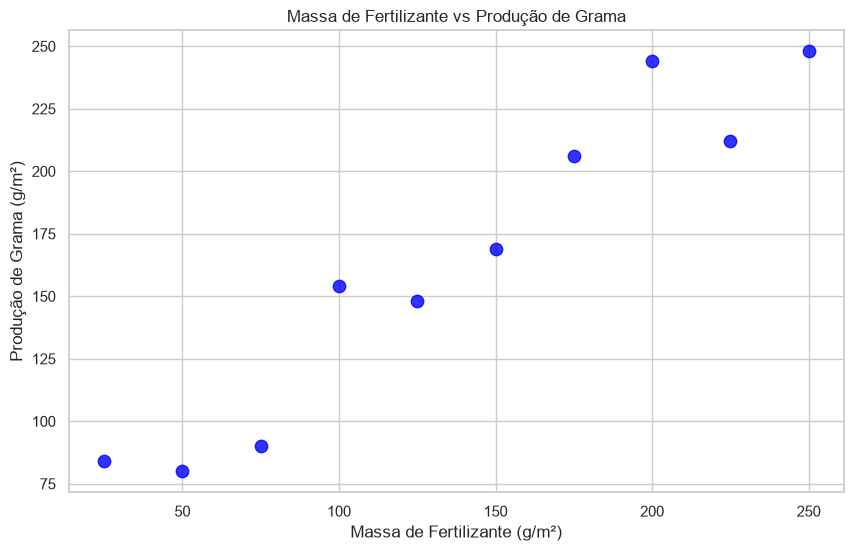

In [4]:
# Dados fornecidos
X = np.array([25, 50, 75, 100, 125, 150, 175, 200, 225, 250])
y = np.array([84, 80, 90, 154, 148, 169, 206, 244, 212, 248])

# Visualizando a relação
plt.scatter(X, y, alpha=0.8, color='blue', s=80)
plt.title('Massa de Fertilizante vs Produção de Grama')
plt.xlabel('Massa de Fertilizante (g/m²)')
plt.ylabel('Produção de Grama (g/m²)')
plt.show()

## 2. Ajuste do Modelo de Regressão
Ajustaremos o modelo de Regressão Linear usando a biblioteca `scikit-learn` e vamos calcular e extrair os resíduos para validação.

In [5]:
# O Scikit-Learn exige que a variável preditora X seja uma matriz 2D
X_reshaped = X.reshape(-1, 1)

# Ajustando o modelo
modelo = LinearRegression()
modelo.fit(X_reshaped, y)

# Extraindo predições e calculando os resíduos (y real - y predito)
valores_preditos = modelo.predict(X_reshaped)
residuos = y - valores_preditos

print(f"Coeficiente (Angular): {modelo.coef_[0]:.4f}")
print(f"Intercepto: {modelo.intercept_:.4f}")
print(f"R² Score (Coeficiente de Determinação): {modelo.score(X_reshaped, y):.4f}")

Coeficiente (Angular): 0.8114
Intercepto: 51.9333
R² Score (Coeficiente de Determinação): 0.9216


## Premissa 1: Independência (Variáveis aleatórias independentes)
Os resíduos ao longo das observações devem se comportar de forma aleatória, sem padrões de sequência. 
Para comprovar, usamos um gráfico de dispersão dos resíduos pelo índice da observação e a estatística.

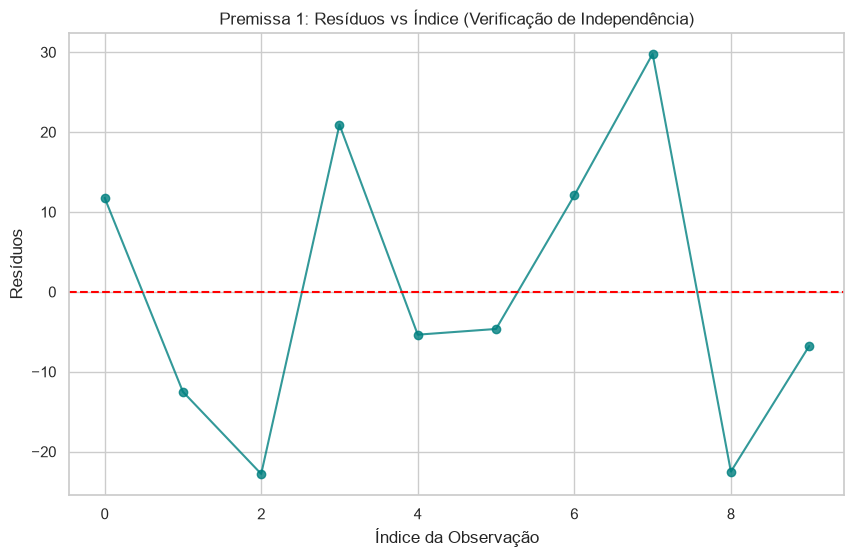

Estatística de Durbin-Watson: 2.38 (Próximo a 2 indica independência dos erros)


In [9]:
plt.plot(residuos, marker='o', linestyle='-', alpha=0.8, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.title('Premissa 1: Resíduos vs Índice (Verificação de Independência)')
plt.xlabel('Índice da Observação')
plt.ylabel('Resíduos')
plt.show()

# Cálculo manual da estatística
dw_stat = np.sum(np.diff(residuos)**2) / np.sum(residuos**2)
print(f"Estatística de Durbin-Watson: {dw_stat:.2f} (Próximo a 2 indica independência dos erros)")

## Premissa 2: Variância Constante (Homocedasticidade)
A dispersão dos erros deve ser igual ao longo de todos os valores preditos. Se houvesse *heterocedasticidade*, veríamos a dispersão aumentando ou diminuindo verticalmente, formando um 'funil' ou 'cone'.

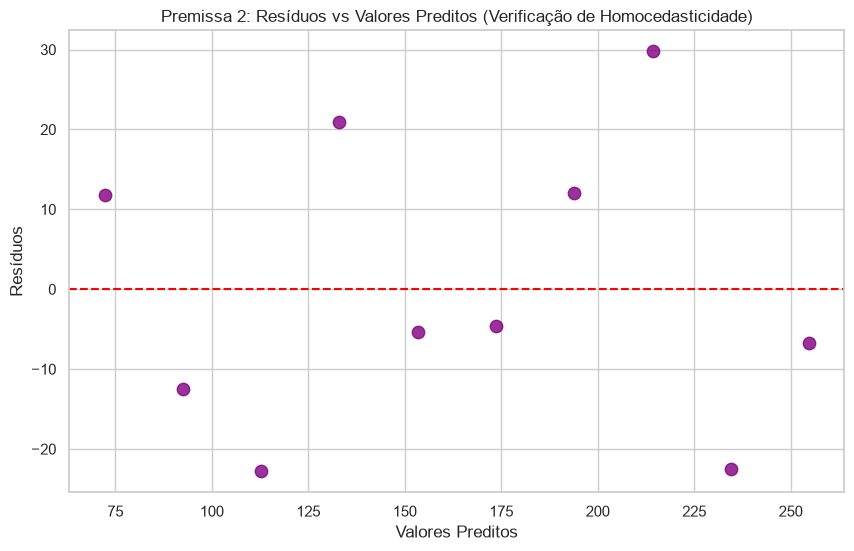

In [7]:
plt.scatter(valores_preditos, residuos, alpha=0.8, color='purple', s=80)
plt.axhline(0, color='red', linestyle='--')
plt.title('Premissa 2: Resíduos vs Valores Preditos (Verificação de Homocedasticidade)')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.show()

## Premissa 3: Distribuição Normal dos Erros
A frequência dos resíduos deve seguir o formato de sino de uma curva Normal ou aproximadamente Normal. O teste visual mais conclusivo costuma ser o **Q-Q plot** (Quantil-Quantil), e podemos usar também o teste de Shapiro-Wilk.

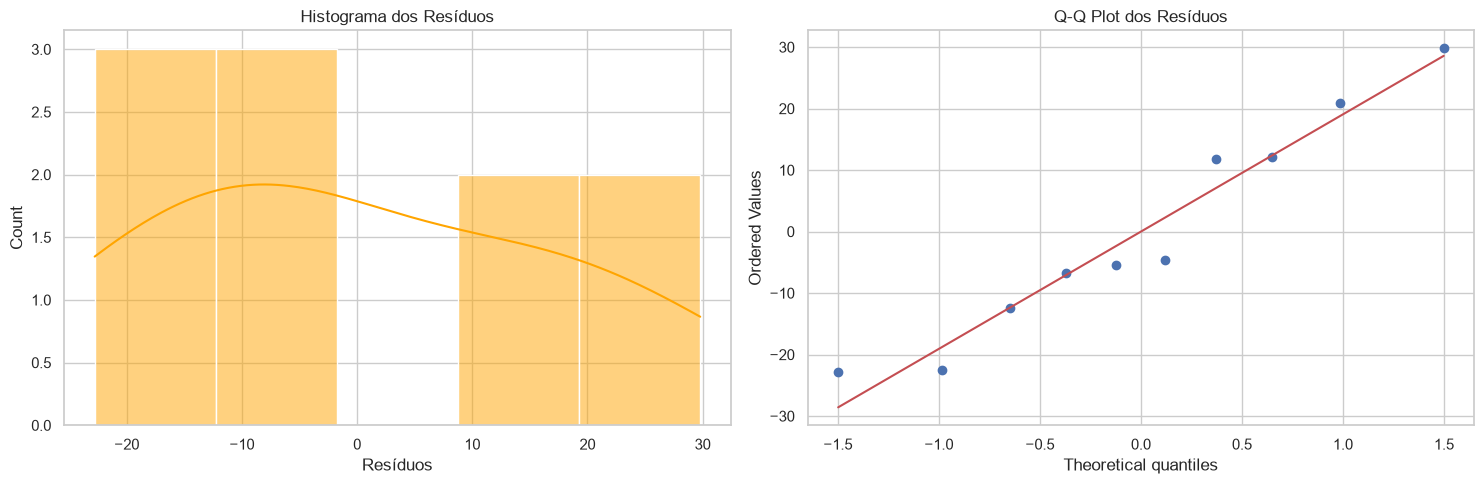

Teste de Shapiro-Wilk - Estatística: 0.9372, p-valor: 0.5227
Conclusão: Não rejeitamos a hipótese nula. Os resíduos parecem seguir uma distribuição normal.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma e curva de densidade KDE
sns.histplot(residuos, kde=True, ax=axes[0], color='orange', bins=5)
axes[0].set_title('Histograma dos Resíduos')
axes[0].set_xlabel('Resíduos')

# Gráfico Q-Q (Quantil-Quantil) via scipy
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout()
plt.show()

# Teste de Shapiro-Wilk para normalidade
stat, p_value = stats.shapiro(residuos)
print(f"Teste de Shapiro-Wilk - Estatística: {stat:.4f}, p-valor: {p_value:.4f}")
if p_value > 0.05:
    print("Conclusão: Não rejeitamos a hipótese nula. Os resíduos parecem seguir uma distribuição normal.")
else:
    print("Conclusão: Rejeitamos a hipótese nula. Os resíduos NÃO parecem seguir uma distribuição normal.")